# 02. 백테스트-추적 통합

BacktestEngine + SignalLogger + OutcomeTracker를 run_and_track() 파이프라인으로 연결하는 실습 노트북.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from smart_stock.data import fetch_stock_cached, Market
from smart_stock.strategies import SMAcrossoverStrategy, RSIStrategy, MACDStrategy
from smart_stock.backtesting import BacktestEngine, run_and_track
from smart_stock.tracking.logger import SignalLogger
from smart_stock.tracking.tracker import OutcomeTracker

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True

## 1. 데이터 로드

In [2]:
ticker = "005930"
df = fetch_stock_cached(ticker, start="2024-01-01", end="2024-12-31")
print(f"기간: {df.index[0].date()} ~ {df.index[-1].date()}, 거래일: {len(df)}일")
df.tail()

기간: 2024-01-02 ~ 2024-12-30, 거래일: 244일


,Open,High,Low,Close,Volume
Date,,,,,
2024-12-23,53400,54000,53300,53500,13672650
2024-12-24,53700,54500,53600,54400,11634677
2024-12-26,54500,54600,53500,53600,10517075
2024-12-27,53500,54100,53200,53700,10747196
2024-12-30,53300,54000,53100,53200,12624702


## 2. 3개 전략 백테스트 + 시그널 기록

In [3]:
# 임시 logger (기본 경로 사용)
logger = SignalLogger()
logger.clear()  # 이전 기록 초기화

strategies = {
    "SMA(5,20)": SMAcrossoverStrategy(short_window=5, long_window=20),
    "RSI(14)": RSIStrategy(period=14),
    "MACD(12,26,9)": MACDStrategy(),
}

results = {}
for name, strategy in strategies.items():
    engine = BacktestEngine(initial_capital=1_000_000)
    result = run_and_track(df, strategy, ticker=ticker, engine=engine, logger=logger)
    results[name] = result
    print(f"[{name}] 수익률: {result.total_return:.2f}%, MDD: {result.mdd:.2f}%, 샤프: {result.sharpe_ratio:.2f}, 승률: {result.win_rate:.1f}%")

[SMA(5,20)] 수익률: -7.84%, MDD: -18.00%, 샤프: -0.47, 승률: 28.6%
[RSI(14)] 수익률: -2.30%, MDD: -10.82%, 샤프: -0.09, 승률: 50.0%
[MACD(12,26,9)] 수익률: -21.13%, MDD: -32.79%, 샤프: -1.04, 승률: 30.0%


## 3. 성과 비교 테이블

In [4]:
summary = pd.DataFrame({
    name: {
        "총수익률(%)": round(r.total_return, 2),
        "MDD(%)": round(r.mdd, 2),
        "샤프지수": round(r.sharpe_ratio, 2),
        "승률(%)": round(r.win_rate, 1),
        "거래횟수": r.trade_count,
    }
    for name, r in results.items()
}).T
summary

,총수익률(%),MDD(%),샤프지수,승률(%),거래횟수
"SMA(5,20)",-7.84,-18.00,-0.47,28.6,7.0
RSI(14),-2.30,-10.82,-0.09,50.0,8.0
"MACD(12,26,9)",-21.13,-32.79,-1.04,30.0,10.0


## 4. 포트폴리오 가치 곡선

/tmp/ipykernel_31847/1698562148.py:8: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31847/1698562148.py:8: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31847/1698562148.py:8: UserWarning: Glyph 54260 (\N{HANGUL SYLLABLE POL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31847/1698562148.py:8: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31847/1698562148.py:8: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31847/1698562148.py:8: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31847/1698562148.py:8: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  plt.tight_layou

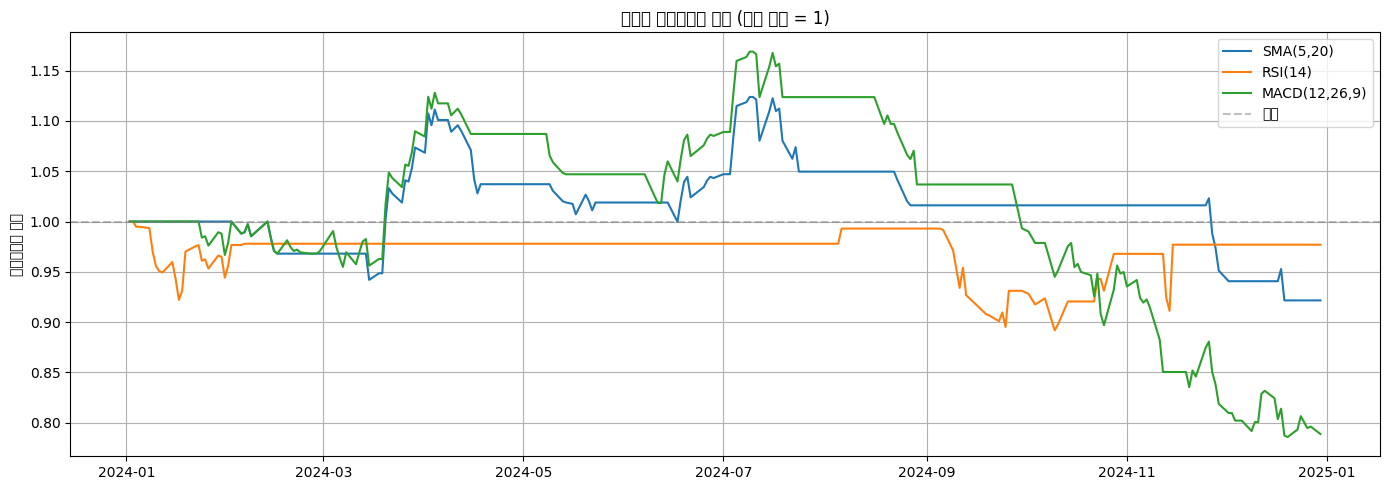

In [5]:
fig, ax = plt.subplots()
for name, result in results.items():
    ax.plot(result.portfolio.index, result.portfolio.values / 1_000_000, label=name)
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5, label="원금")
ax.set_title("전략별 포트폴리오 가치 (초기 자본 = 1)")
ax.set_ylabel("포트폴리오 배율")
ax.legend()
plt.tight_layout()
plt.show()

## 5. 기록된 시그널 확인

In [6]:
signals_df = logger.load()
print(f"총 시그널 수: {len(signals_df)}")
signals_df.head(10)

총 시그널 수: 49


,strategy_name,ticker,signal_date,signal,price,logged_at
0,SMAcrossoverStrategy,005930,2024-02-02,1,75200.0,2026-03-17 11:06:37.147217
1,SMAcrossoverStrategy,005930,2024-02-16,-1,72800.0,2026-03-17 11:06:37.151267
2,SMAcrossoverStrategy,005930,2024-03-14,1,74300.0,2026-03-17 11:06:37.158684
3,SMAcrossoverStrategy,005930,2024-04-18,-1,79600.0,2026-03-17 11:06:37.165400
4,SMAcrossoverStrategy,005930,2024-05-09,1,79700.0,2026-03-17 11:06:37.170900
5,SMAcrossoverStrategy,005930,2024-05-23,-1,78300.0,2026-03-17 11:06:37.176435
6,SMAcrossoverStrategy,005930,2024-06-14,1,79600.0,2026-03-17 11:06:37.180462
7,SMAcrossoverStrategy,005930,2024-07-24,-1,82000.0,2026-03-17 11:06:37.183940
8,SMAcrossoverStrategy,005930,2024-08-21,1,78300.0,2026-03-17 11:06:37.188066
9,SMAcrossoverStrategy,005930,2024-08-27,-1,75800.0,2026-03-17 11:06:37.193153


## 6. 매수/매도 시그널 달력 시각화

/tmp/ipykernel_31847/3704949453.py:18: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31847/3704949453.py:18: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31847/3704949453.py:18: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31847/3704949453.py:18: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31847/3704949453.py:18: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31847/3704949453.py:18: UserWarning: Glyph 45328 (\N{HANGUL SYLLABLE NEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31847/3704949453.py:18: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.ti

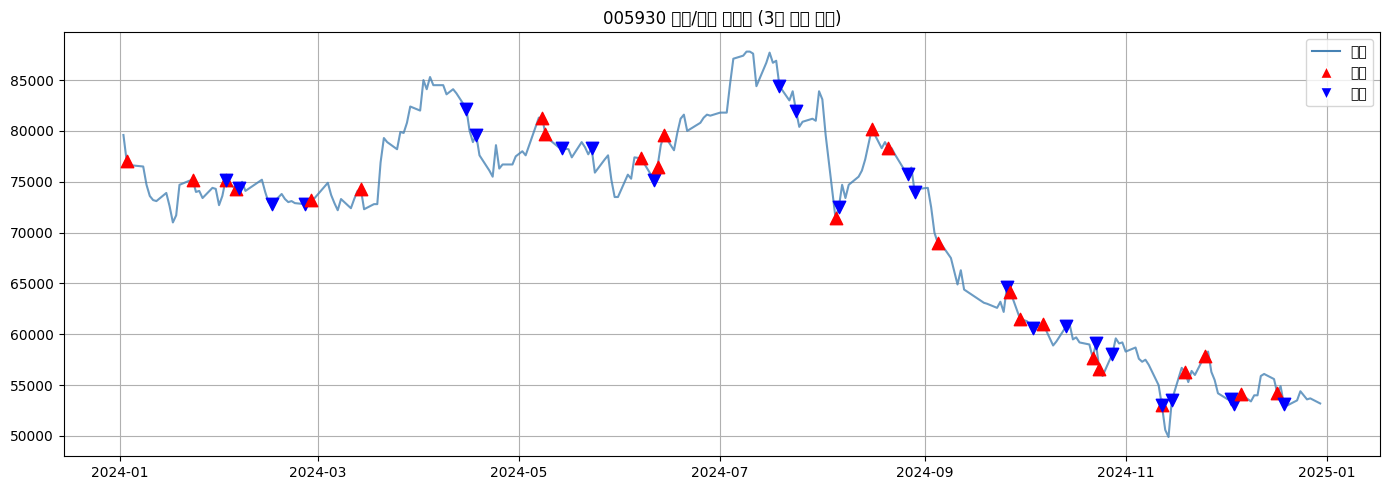

In [7]:
fig, ax = plt.subplots()
ax.plot(df.index, df["Close"], color="steelblue", alpha=0.8, label="종가")

for _, row in signals_df.iterrows():
    if int(row["signal"]) == 1:
        ax.scatter(row["signal_date"], row["price"], marker="^", color="red", s=80, zorder=5)
    elif int(row["signal"]) == -1:
        ax.scatter(row["signal_date"], row["price"], marker="v", color="blue", s=80, zorder=5)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color="steelblue", label="종가"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="red", markersize=8, label="매수"),
    Line2D([0], [0], marker="v", color="w", markerfacecolor="blue", markersize=8, label="매도"),
]
ax.legend(handles=legend_elements)
ax.set_title(f"{ticker} 매수/매도 시그널 (3개 전략 합산)")
plt.tight_layout()
plt.show()

## 7. 결과 추적 (OutcomeTracker)

In [8]:
# 실제 과거 데이터이므로 fetch_stock_cached 재사용
tracker = OutcomeTracker()
outcomes_df = tracker.update(signals_df)
print(f"총 추적 시그널: {len(outcomes_df)}")
outcomes_df[["strategy_name", "ticker", "signal_date", "signal", "entry_price", "outcome_1d", "outcome_1w"]].head(10)

총 추적 시그널: 49


,strategy_name,ticker,signal_date,signal,entry_price,outcome_1d,outcome_1w
0,SMAcrossoverStrategy,005930,2024-02-02,1,75200.0,-1.196809,0.000000
1,SMAcrossoverStrategy,005930,2024-02-16,-1,72800.0,1.373626,0.137363
2,SMAcrossoverStrategy,005930,2024-03-14,1,74300.0,-2.691790,6.729475
3,SMAcrossoverStrategy,005930,2024-04-18,-1,79600.0,-2.512563,-4.145729
4,SMAcrossoverStrategy,005930,2024-05-09,1,79700.0,-0.627353,-2.885822
5,SMAcrossoverStrategy,005930,2024-05-23,-1,78300.0,-3.065134,-6.130268
6,SMAcrossoverStrategy,005930,2024-06-14,1,79600.0,-1.884422,0.502513
7,SMAcrossoverStrategy,005930,2024-07-24,-1,82000.0,-1.951220,2.317073
8,SMAcrossoverStrategy,005930,2024-08-21,1,78300.0,0.000000,-2.426564
9,SMAcrossoverStrategy,005930,2024-08-27,-1,75800.0,0.791557,-4.353562
